In [1]:
import os
os.chdir('../../../../..')

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pyriemann.tangentspace import TangentSpace
import umap
import seaborn as sns
from loguru import logger
from sklearn.manifold import TSNE, MDS

from src.datasets import QM9Dataset
from src.non_euclidean import Riemann
from src.helper_functions import create_chemiscope_viewer

In [3]:
qm9 = QM9Dataset(limit=80_000, sampling_strategy="stratified", descriptors=["soap"])
df = qm9.load()

2026-05-26 09:58:10.953 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-26 09:58:11.418 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=80000, returned_rows=80000, sampling on columns=['num_atoms', 'gap'].
2026-05-26 09:58:11.424 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=80000).
2026-05-26 09:58:11.507 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-26 10:01:21.478 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-26 10:01:21.585 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-26 10:01:21.745 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering 

In [4]:
from dscribe.kernels import REMatchKernel

def rematch_kernel_dist_matrix(df, metric="linear", alpha=0.1, tol=1e-3):

    soap_matrices = df["soap_matrix"].to_list()

    cleaned = []

    normalized = False
    for i, x in enumerate(soap_matrices):
        x = np.asarray(x, dtype=np.float64)

        # shape check
        if x.ndim != 2:
            raise ValueError(f"SOAP matrix {i} is not 2D: shape={x.shape}")

        # finite check
        if not np.isfinite(x).all():
            raise ValueError(f"Non-finite values in SOAP matrix {i}")

        # ----------------------------
        # Check if already normalized
        # ----------------------------
        norms = np.linalg.norm(x, axis=1)

        already_normalized = np.all(np.abs(norms - 1.0) < tol)

        if already_normalized:
            x_norm = x
            normalized = True
            cleaned = soap_matrices
            logger.info("Descriptor is already normalized")
            if normalized:
                break
        else:
            x_norm = x / (norms[:, None] + 1e-12)
        

        # final sanity check
        if not np.isfinite(x_norm).all():
            raise ValueError(f"NaN/inf after normalization in matrix {i}")

        cleaned.append(x_norm)

    # ----------------------------
    # REMatch kernel
    # ----------------------------
    kernel = REMatchKernel(
        metric=metric,
        alpha=alpha
    )

    print("Computing REMatch kernel matrix...")
    K = kernel.create(cleaned)

    if not np.isfinite(K).all():
        raise ValueError("Kernel matrix contains NaN or inf")

    # ----------------------------
    # Distance conversion
    # ----------------------------
    diag = np.diag(K)
    dist_sq = diag[:, None] + diag[None, :] - 2.0 * K

    dist_sq = np.clip(dist_sq, 0.0, None)
    D = np.sqrt(dist_sq)

    np.fill_diagonal(D, 0.0)
    D = (D + D.T) / 2.0

    return D

# Hypothesis 1
- goal is to show that some molecules can not be well seperaeted by ReMatch kernel. These molecules could be highly structural/constitutional isomers with identical local chemical environments but radically different global topologies
- method: compare cyclic vs linear isomers. choose C6H10. 
- reason: the local hybridization will look very similar for rematch kernel. However, because the structural variations are constrained to a ring vs. stretched along a chain, the features will co-vary differently across the atoms, creating distinct covariance footprints

In [5]:
df = df.filter(pl.col("num_atoms") > 7) # works better on riemann

df_C5H8O = df.filter(pl.col("formula") == "C5H8O")
df_C7H10O2 = df.filter(pl.col("formula") == "C7H10O2").sample(500, with_replacement=True)
print(df_C7H10O2.shape)

(500, 72)


In [6]:
riemann = Riemann()
dist_matrix_riemann = riemann.distance_matrix(df_C7H10O2, "soap", distance_type='affine-invariant')
labels = [i for i in range(len(df_C7H10O2))]


2026-05-26 10:01:24.200 | INFO     | src.non_euclidean:distance_matrix:1114 - Computing Riemann distance matrix | Features: soap | Distance: affine-invariant
2026-05-26 10:01:24.203 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-26 10:01:27.155 | INFO     | src.non_euclidean:distance_matrix:1124 - Computing affine-invariant distances...


In [7]:
dist_matrix_rematch = rematch_kernel_dist_matrix(df_C7H10O2)

2026-05-26 10:05:54.710 | INFO     | __main__:rematch_kernel_dist_matrix:32 - Descriptor is already normalized


Computing REMatch kernel matrix...


In [8]:
create_chemiscope_viewer(df_C7H10O2, dist_matrix_riemann, labels, 'UMAP')

2026-05-26 10:06:37.508 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-26 10:06:37.512 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-26 10:06:42.280 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 15
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecate

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

In [9]:
create_chemiscope_viewer(df_C7H10O2, dist_matrix_rematch, labels, 'UMAP')

2026-05-26 10:06:46.249 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-26 10:06:46.249 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-26 10:06:50.647 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 15
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-26 10:06:51.042 | INFO     | src.helper_

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

# Hypothesis 2
- the ring size clustering from SOAP

In [15]:
from rdkit import Chem

def categorize_pure_carbocycle(smiles: str) -> str:
    """
    Parses a SMILES string. 
    Returns '3-ring' or '6-ring' ONLY if the ring is made entirely of Carbon.
    Rejects heterocycles (rings with O, N, F).
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or "O" in smiles or "N" in smiles:
        return "Other"
    
    # Get ring information
    ring_info = mol.GetRingInfo().AtomRings()
    
    # Reject acyclic molecules
    if not ring_info:
        return "Acyclic"
        
    # Check if ALL rings are pure Carbon (Atomic Number == 6)
    for ring in ring_info:
        for atom_idx in ring:
            atom = mol.GetAtomWithIdx(atom_idx)
            if atom.GetAtomicNum() != 6:
                return "Heterocycle" # Reject if the ring contains O, N, F, etc.
                
    # Extract unique ring sizes
    sizes = set(len(ring) for ring in ring_info)
    
    # Return valid pure carbocycles
    if sizes == {3}:
        return "3-ring"
    elif sizes == {6}:
        return "6-ring"
    else:
        return "Mixed/Other"

# 1. Apply the strict function
print("Categorizing rings and enforcing carbocycles using RDKit...")
df = df.with_columns(
    pl.col("smiles")
    .map_elements(categorize_pure_carbocycle, return_dtype=pl.Utf8)
    .alias("ring_category")
)

# 1. Start with the fully categorized dataset (NO heavy atom filter yet)
df_3_rings_all = df.filter(pl.col("ring_category") == "3-ring")
df_6_rings_all = df.filter(pl.col("ring_category") == "6-ring")

# 2. Count the occurrences of each formula in both groups
counts_3 = df_3_rings_all.group_by("formula").len().rename({"len": "count_3"})
counts_6 = df_6_rings_all.group_by("formula").len().rename({"len": "count_6"})

# 3. Join the counts to find formulas that exist in BOTH groups
formula_overlap = counts_3.join(counts_6, on="formula", how="inner")

# 4. Calculate the bottleneck (the maximum possible balanced sample size)
# The max size is constrained by whichever group has fewer molecules
formula_overlap = formula_overlap.with_columns(
    pl.min_horizontal("count_3", "count_6").alias("max_balanced_size")
).sort("max_balanced_size", descending=True)

# Let's see the top 5 formulas in the whole dataset for this experiment
print("Top 5 optimal formulas for the strain experiment:")
print(formula_overlap.head(10))

# 5. Extract the absolute best formula
if formula_overlap.height == 0:
    raise ValueError("No shared formulas found in the dataset!")

best_row = formula_overlap.row(0, named=True)
best_formula = best_row["formula"]
max_size = best_row["max_balanced_size"]

print(f"\nStrict Control Triggered: Restricting entire experiment to {best_formula}")
print(f"This allows for a perfectly balanced dataset of {max_size} vs {max_size} molecules.")

# 6. Create the final perfectly balanced dataset
df_3_sampled = df_3_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
df_6_sampled = df_6_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)

df_strain_experiment = pl.concat([df_3_sampled, df_6_sampled])
print(f"Final experimental dataset shape: {df_strain_experiment.height} molecules.")

Categorizing rings and enforcing carbocycles using RDKit...
Top 5 optimal formulas for the strain experiment:
shape: (10, 4)
┌─────────┬─────────┬─────────┬───────────────────┐
│ formula ┆ count_3 ┆ count_6 ┆ max_balanced_size │
│ ---     ┆ ---     ┆ ---     ┆ ---               │
│ str     ┆ u32     ┆ u32     ┆ u32               │
╞═════════╪═════════╪═════════╪═══════════════════╡
│ C9H16   ┆ 27      ┆ 31      ┆ 27                │
│ C9H12   ┆ 12      ┆ 23      ┆ 12                │
│ C9H14   ┆ 71      ┆ 7       ┆ 7                 │
│ C9H18   ┆ 57      ┆ 5       ┆ 5                 │
│ C8H14   ┆ 6       ┆ 5       ┆ 5                 │
│ C8H16   ┆ 23      ┆ 3       ┆ 3                 │
│ C8H12   ┆ 19      ┆ 2       ┆ 2                 │
│ C8H10   ┆ 2       ┆ 7       ┆ 2                 │
│ C7H12   ┆ 2       ┆ 2       ┆ 2                 │
│ C6H10   ┆ 1       ┆ 1       ┆ 1                 │
└─────────┴─────────┴─────────┴───────────────────┘

Strict Control Triggered: Restricting enti

In [16]:
df_strain_experiment = df_strain_experiment.with_columns(
    ring_labels = pl.when(pl.col("ring_category") == "3-ring")
                    .then(3)
                    .otherwise(6)
)

dist_matrix_rematch_rings = rematch_kernel_dist_matrix(df_strain_experiment)

riemann = Riemann()
dist_matrix_riemann_log_rings = riemann.distance_matrix(
    df_strain_experiment, "soap", distance_type="log-euclidean"
)

dist_matrix_riemann_affine_rings = riemann.distance_matrix(
    df_strain_experiment, "soap", distance_type="affine-invariant"
)


2026-05-26 10:46:22.133 | INFO     | __main__:rematch_kernel_dist_matrix:32 - Descriptor is already normalized


Computing REMatch kernel matrix...


2026-05-26 10:46:22.729 | INFO     | src.non_euclidean:distance_matrix:1114 - Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
2026-05-26 10:46:22.730 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-26 10:46:23.141 | INFO     | src.non_euclidean:distance_matrix:1124 - Computing log-euclidean distances...
2026-05-26 10:46:23.311 | INFO     | src.non_euclidean:distance_matrix:1114 - Computing Riemann distance matrix | Features: soap | Distance: affine-invariant
2026-05-26 10:46:23.311 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-26 10:46:23.622 | INFO     | src.non_euclidean:distance_matrix:1124 - Computing affine-invariant distances...


In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP
from sklearn.metrics import silhouette_score

def run_strain_topology_comparison(
    df: pl.DataFrame,
    d_rematch: np.ndarray,
    d_log_euclidean: np.ndarray,
    d_affine: np.ndarray,
    label_col: str = "ring_category"
) -> None:
    """
    Computes custom distance-matrix metrics (Intra, Inter, Separation Ratio, Silhouette)
    and generates a publication-quality side-by-side UMAP plot.
    """
    # 1. Map raw labels to report-ready descriptive strings
    raw_labels = df.get_column(label_col).to_numpy()
    legend_labels = np.where(raw_labels == "3-ring", "Strained (3-Membered)", "Relaxed (6-Membered)")
    unique_classes = np.unique(legend_labels)

    matrices = {
        "SOAP (REMatch Kernel)": d_rematch,
        "Log-Euclidean Riemannian": d_log_euclidean,
        "Affine-Invariant Riemannian": d_affine
    }

    # Dictionary to hold metrics for the summary table
    metrics_summary = {}

    # 2. Compute Distance-Matrix Topological Metrics
    for name, dist_matrix in matrices.items():
        # A. Silhouette Score (Supports precomputed metrics out-of-the-box)
        sil = silhouette_score(dist_matrix, legend_labels, metric="precomputed")

        # B. Intra-class Distance (Mean distance between elements within the same cluster)
        intra_dists = []
        for cls in unique_classes:
            idx = np.where(legend_labels == cls)[0]
            sub_matrix = dist_matrix[np.ix_(idx, idx)]
            # Use upper triangle to exclude diagonal zeros and avoid double counting
            triu_idx = np.triu_indices(len(idx), k=1)
            intra_dists.append(np.mean(sub_matrix[triu_idx]))
        mean_intra = np.mean(intra_dists)

        # C. Inter-class Distance (Mean distance between elements of differing clusters)
        idx_strained = np.where(legend_labels == "Strained (3-Membered)")[0]
        idx_relaxed = np.where(legend_labels == "Relaxed (6-Membered)")[0]
        inter_matrix = dist_matrix[np.ix_(idx_strained, idx_relaxed)]
        mean_inter = np.mean(inter_matrix)

        # D. Separation Ratio (Intra / Inter) -> Lower values mean cleaner separation
        separation_ratio = mean_intra / mean_inter

        metrics_summary[name] = {
            "Silhouette": sil,
            "Intra-Class": mean_intra,
            "Inter-Class": mean_inter,
            "Sep-Ratio": separation_ratio
        }

    # Print clean console table
    print("\n" + "="*85)
    print(f"{'Framework / Metric':<30} | {'Intra-Class (↓)':<15} | {'Inter-Class (↑)':<15} | {'Sep Ratio (↓)':<13} | {'Silhouette (↑)':<12}")
    print("-" * 85)
    for name, m in metrics_summary.items():
        print(f"{name:<30} | {m['Intra-Class']:<15.4f} | {m['Inter-Class']:<15.4f} | {m['Sep-Ratio']:<13.4f} | {m['Silhouette']:<12.4f}")
    print("="*85 + "\n")

    # 3. Initialize Report Theme Settings
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), dpi=300)
    palette = {"Strained (3-Membered)": "#cc5e53", "Relaxed (6-Membered)": "#568bbd"}

    # 4. Process and Plot Each Framework
    for ax, (name, dist_matrix) in zip(axes, matrices.items()):
        print(f"Computing UMAP projection from precomputed {name} matrix...")
        
        reducer = UMAP(n_neighbors=5, metric="precomputed", random_state=42)
        umap_coords = reducer.fit_transform(dist_matrix)

        sns.scatterplot(
            x=umap_coords[:, 0],
            y=umap_coords[:, 1],
            hue=legend_labels,
            palette=palette,
            s=90,
            alpha=0.85,
            edgecolors="#2d3436",
            linewidths=0.8,
            ax=ax,
            zorder=10,
        )

        ax.set_title(
            f"{name}",
            fontsize=13,
            fontweight="bold",
            pad=15,
        )
        ax.set_xlabel("UMAP Dimension 1", fontsize=10, fontweight="medium")
        ax.set_ylabel("UMAP Dimension 2", fontsize=10, fontweight="medium")
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.get_legend().remove()
        sns.despine(ax=ax)

    # 5. Generate Unified Global Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Ring Topology (6 Heavy Atoms)",
        title_fontsize=11,
        fontsize=10,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=2,
        frameon=True,
        facecolor="white",
        edgecolor="#e2e8f0",
    )

    plt.tight_layout()
    output_filename = "riemann_strain_comparison.png"
    print(f"Saved high-res comparison plot to {output_filename}")
    plt.show()


Framework / Metric             | Intra-Class (↓) | Inter-Class (↑) | Sep Ratio (↓) | Silhouette (↑)
-------------------------------------------------------------------------------------
SOAP (REMatch Kernel)          | 0.1423          | 0.1542          | 0.9228        | 0.0768      
Log-Euclidean Riemannian       | 7.9730          | 8.9664          | 0.8892        | 0.1097      
Affine-Invariant Riemannian    | 9.5641          | 10.7232         | 0.8919        | 0.1077      

Computing UMAP projection from precomputed SOAP (REMatch Kernel) matrix...
Computing UMAP projection from precomputed Log-Euclidean Riemannian matrix...
Computing UMAP projection from precomputed Affine-Invariant Riemannian matrix...
Saved high-res comparison plot to riemann_strain_comparison.png


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden t

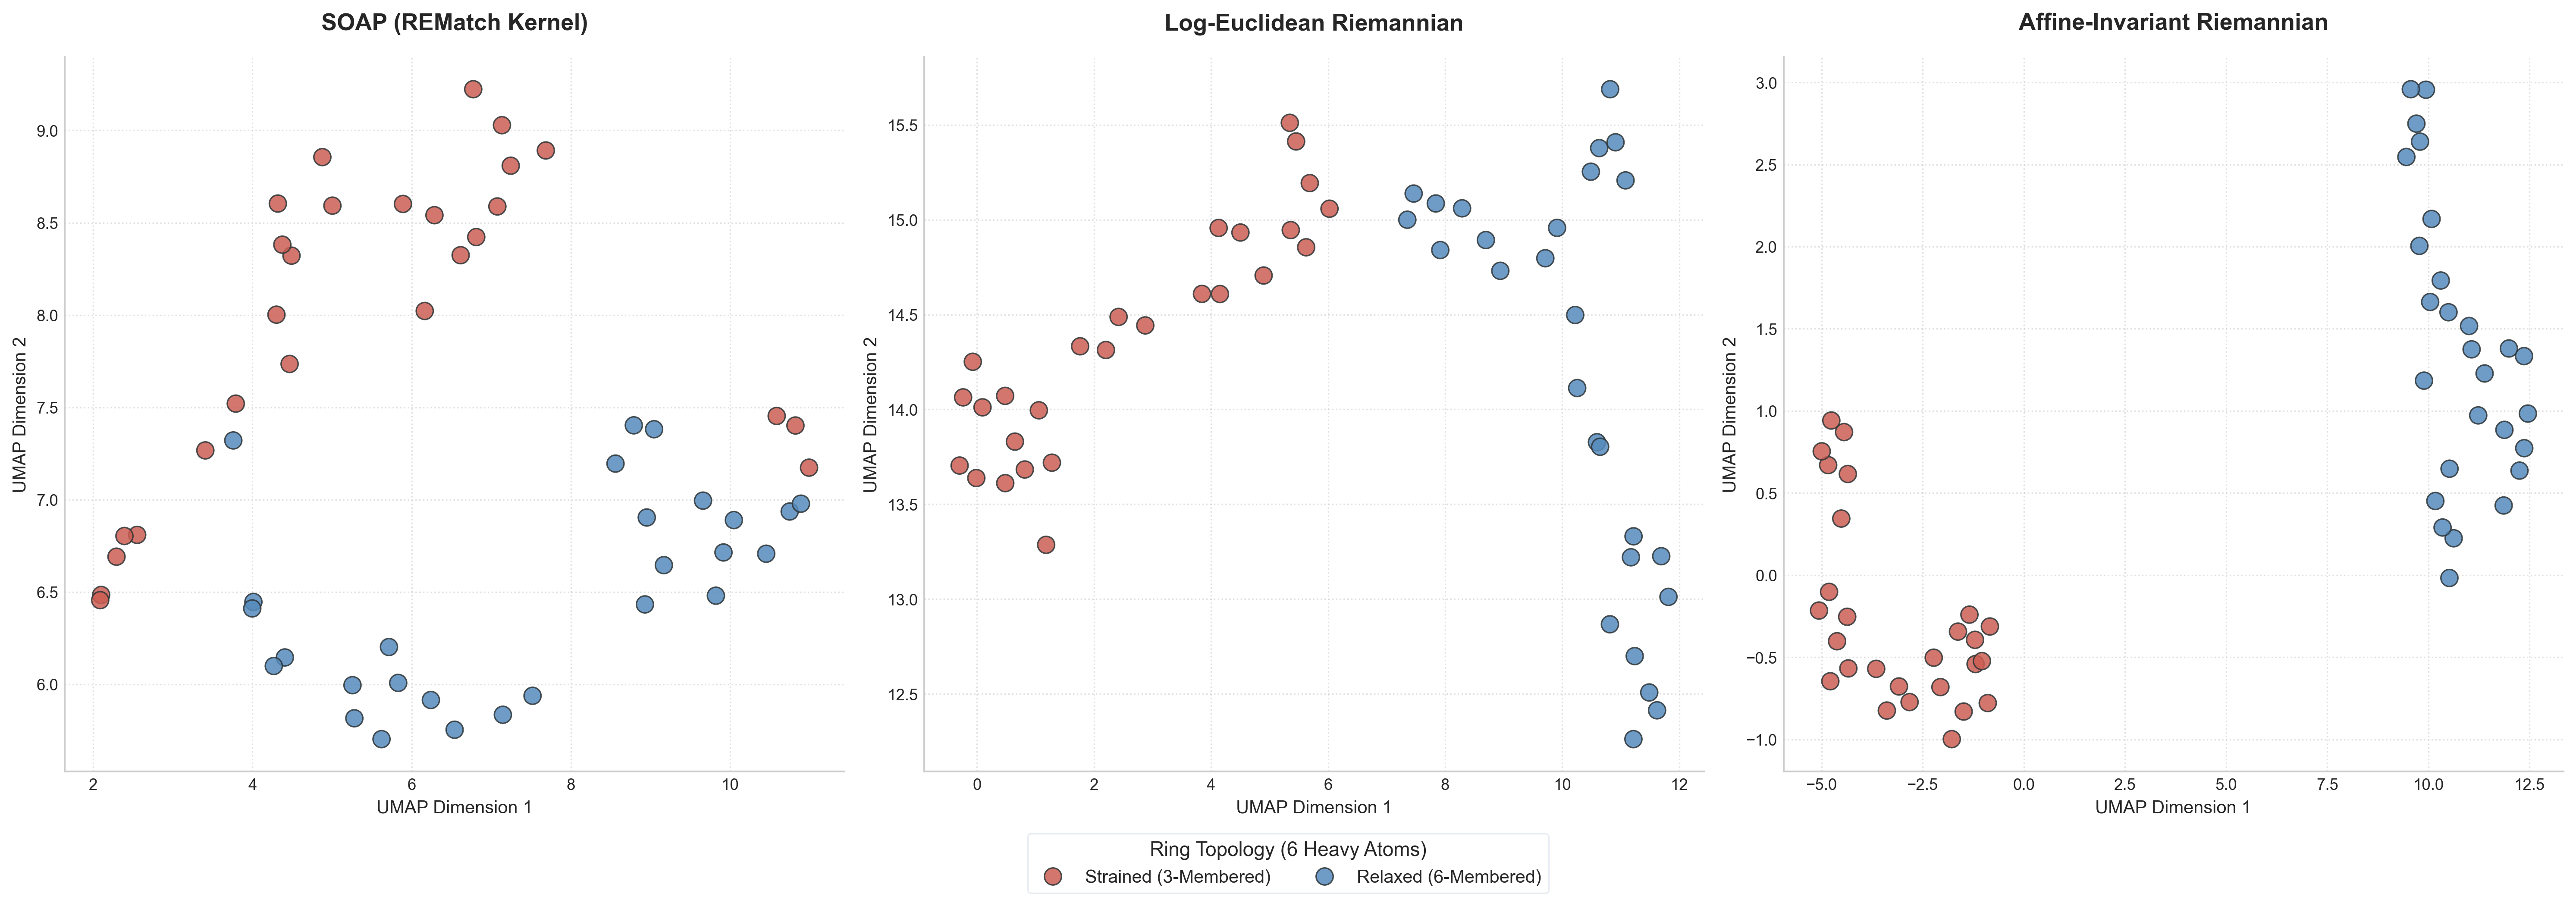

In [27]:
run_strain_topology_comparison(
    df=df_strain_experiment,
    d_rematch=dist_matrix_rematch_rings,
    d_log_euclidean=dist_matrix_riemann_log_rings,
    d_affine=dist_matrix_riemann_affine_rings,
    label_col="ring_category"
)

# Hypothesis 3

In [10]:
import numpy as np
import polars as pl
from scipy.stats import spearmanr
from sklearn.metrics import silhouette_score

riemann = Riemann()
dist_matrix_riemann_log = riemann.distance_matrix(
    df_C7H10O2, "soap", distance_type="log-euclidean"
)

dist_matrix_riemann_affine = riemann.distance_matrix(
    df_C7H10O2, "soap", distance_type="affine-invariant"
)

dist_matrix_rematch = rematch_kernel_dist_matrix(df_C7H10O2)

2026-05-26 10:06:51.093 | INFO     | src.non_euclidean:distance_matrix:1114 - Computing Riemann distance matrix | Features: soap | Distance: log-euclidean
2026-05-26 10:06:51.094 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-26 10:06:53.905 | INFO     | src.non_euclidean:distance_matrix:1124 - Computing log-euclidean distances...
2026-05-26 10:06:55.543 | INFO     | src.non_euclidean:distance_matrix:1114 - Computing Riemann distance matrix | Features: soap | Distance: affine-invariant
2026-05-26 10:06:55.543 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df
2026-05-26 10:06:58.348 | INFO     | src.non_euclidean:distance_matrix:1124 - Computing affine-invariant distances...
2026-05-26 10:11:30.415 | INFO     | __main__:rematch_kernel_dist_matrix:32 - Descriptor is already normalized


Computing REMatch kernel matrix...


In [11]:
matrices = {
    "Log-Euclidean": dist_matrix_riemann_log,
    "Affine-Invariant": dist_matrix_riemann_affine,
    "REMatch": dist_matrix_rematch,
}

for name, mat in matrices.items():

    print(f"\n{name}")
    print("-" * 50)

    # NaN / Inf checks
    has_nan = np.isnan(mat).any()
    has_inf = np.isinf(mat).any()

    print(f"Contains NaN          : {has_nan}")
    print(f"Contains Inf          : {has_inf}")

    # Symmetry
    is_symmetric = np.allclose(mat, mat.T, atol=1e-8)
    print(f"Symmetric             : {is_symmetric}")

    # Diagonal checks
    diagonal = np.diag(mat)

    diag_all_zero = np.allclose(diagonal, 0.0, atol=1e-8)
    max_diag_abs = np.max(np.abs(diagonal))

    print(f"Diagonal all zeros    : {diag_all_zero}")
    print(f"Max |diagonal value|  : {max_diag_abs:.6e}")

    # Range
    print(f"Min value             : {np.nanmin(mat):.6f}")
    print(f"Max value             : {np.nanmax(mat):.6f}")

    # Optional: show problematic indices
    if has_nan:
        nan_idx = np.argwhere(np.isnan(mat))
        print(f"NaN indices (first 10):\n{nan_idx[:10]}")

    if has_inf:
        inf_idx = np.argwhere(np.isinf(mat))
        print(f"Inf indices (first 10):\n{inf_idx[:10]}")


Log-Euclidean
--------------------------------------------------
Contains NaN          : False
Contains Inf          : False
Symmetric             : True
Diagonal all zeros    : True
Max |diagonal value|  : 0.000000e+00
Min value             : 0.000000
Max value             : 26.268116

Affine-Invariant
--------------------------------------------------
Contains NaN          : False
Contains Inf          : False
Symmetric             : True
Diagonal all zeros    : True
Max |diagonal value|  : 0.000000e+00
Min value             : 0.000000
Max value             : 26.955321

REMatch
--------------------------------------------------
Contains NaN          : False
Contains Inf          : False
Symmetric             : True
Diagonal all zeros    : True
Max |diagonal value|  : 0.000000e+00
Min value             : 0.000000
Max value             : 0.571092


In [12]:
def run_topology_benchmark(
    df: pl.DataFrame,
    D_rematch: np.ndarray,
    D_riemann_affine: np.ndarray,
    D_riemann_log: np.ndarray,
) -> None:
    """
    Evaluates how well REMatch vs Affine-Invariant Riemannian vs
    Log-Euclidean Riemannian distance matrices capture global molecular shape.

    Uses the exact rows present in the provided dataframe.
    """

    N = df.height

    # ============================================================
    # Safety checks
    # ============================================================
    expected_shape = (N, N)

    matrices = {
        "REMatch": D_rematch,
        "Affine Riemann": D_riemann_affine,
        "Log-Euclidean": D_riemann_log,
    }

    for name, mat in matrices.items():
        if mat.shape != expected_shape:
            raise ValueError(
                f"{name} matrix has shape {mat.shape}, "
                f"expected {expected_shape}."
            )

        if np.isnan(mat).any():
            raise ValueError(f"{name} matrix contains NaN values.")

        if np.isinf(mat).any():
            raise ValueError(f"{name} matrix contains Inf values.")

    # ============================================================
    # Upper triangles for pairwise comparisons
    # ============================================================
    triu_idx = np.triu_indices(N, k=1)

    flat_matrices = {
        name: mat[triu_idx]
        for name, mat in matrices.items()
    }

    print(f"Running benchmark on {N} aligned molecules.\n")

    # ============================================================
    # ANALYSIS A: CORRELATION WITH MOLECULAR FEATURES
    # ============================================================
    print("=== Analysis A: Global Shape Correlation (Spearman ρ) ===")

    header = (
        f"{'QM9 Feature':<15} | "
        f"{'REMatch':<12} | "
        f"{'Affine Riemann':<18} | "
        f"{'Log-Euclidean':<15}"
    )

    print(header)
    print("-" * len(header))

    shape_features = [
        "mu",
        "alpha",
        "homo",
        "lumo",
        "gap",
        "r2",
        "zpve",
        "u0",
        "u",
        "h",
        "g",
        "cv",
        "u0_atom",
        "u_atom",
        "h_atom",
        "g_atom",
        "A",
        "B",
        "C",
    ]

    for feat in shape_features:

        if feat not in df.columns:
            continue

        feat_vals = df.get_column(feat).to_numpy()

        # Pairwise absolute differences
        D_feat = np.abs(feat_vals[:, None] - feat_vals[None, :])
        flat_feat = D_feat[triu_idx]

        correlations = {}

        for name, flat_dist in flat_matrices.items():
            corr, _ = spearmanr(flat_dist, flat_feat)
            correlations[name] = corr

        print(
            f"{feat:<15} | "
            f"{correlations['REMatch']:<12.4f} | "
            f"{correlations['Affine Riemann']:<18.4f} | "
            f"{correlations['Log-Euclidean']:<15.4f}"
        )

    # ============================================================
    # ANALYSIS B: CLUSTER SEPARATION
    # ============================================================
    print("\n=== Analysis B: Clustering Performance (Silhouette Score) ===")

    target_classes = [
        "structure_class",
        "num_rings",
    ]

    for target_col in target_classes:

        if target_col not in df.columns:
            continue

        labels = df.get_column(target_col).to_numpy()

        unique_classes = len(np.unique(labels))

        if not (1 < unique_classes < N):
            print(
                f"\nTarget Class '{target_col}' skipped: "
                f"requires between 2 and {N-1} unique classes "
                f"(found {unique_classes})."
            )
            continue

        print(f"\nTarget Class: {target_col}")

        for name, mat in matrices.items():

            sil = silhouette_score(
                mat,
                labels,
                metric="precomputed",
            )

            print(f"  -> {name:<17} : {sil:.4f}")


run_topology_benchmark(
    df=df_C7H10O2,
    D_rematch=dist_matrix_rematch,
    D_riemann_affine=dist_matrix_riemann_affine,
    D_riemann_log=dist_matrix_riemann_log,
)

Running benchmark on 500 aligned molecules.

=== Analysis A: Global Shape Correlation (Spearman ρ) ===
QM9 Feature     | REMatch      | Affine Riemann     | Log-Euclidean  
---------------------------------------------------------------------
mu              | 0.0104       | 0.0119             | 0.0086         
alpha           | 0.5357       | 0.4683             | 0.4575         
homo            | 0.1214       | 0.0846             | 0.0824         
lumo            | 0.0409       | 0.0429             | 0.0401         
gap             | 0.0186       | 0.0230             | 0.0198         
r2              | 0.5984       | 0.5329             | 0.5150         
zpve            | 0.3703       | 0.4405             | 0.4391         
u0              | 0.0811       | 0.0591             | 0.0540         
u               | 0.0903       | 0.0696             | 0.0647         
h               | 0.0903       | 0.0696             | 0.0647         
g               | 0.0677       | 0.0432             | 0.0

# Hypothesis 2

In [13]:
def manual_log_euclidean_vectorize(spd_matrices: np.ndarray) -> np.ndarray:
    """Manually computes the Log-Euclidean vectorization of a tensor of SPD matrices.
    
    Weights off-diagonal elements by sqrt(2) to preserve the Riemannian metric inner product.
    """
    N_molecules, d, _ = spd_matrices.shape
    triu_idx = np.triu_indices(d)
    
    # Generate an explicit weight matrix: 1.0 on diagonal, sqrt(2) on off-diagonals
    weight_matrix = np.where(np.eye(d, dtype=bool), 1.0, np.sqrt(2.0))
    
    vectorized_dataset = []
    
    # Create a list to collect the minimum eigenvalue of each matrix for logging
    all_min_eigenvalues = []
    
    for C in spd_matrices:
        # 1. Stable Matrix Logarithm for Symmetric Positive Definite matrices
        eigenvalues, eigenvectors = np.linalg.eigh(C)
        
        # Track the minimum eigenvalue found in this specific matrix
        all_min_eigenvalues.append(eigenvalues.min())
        
        # Micro-safety clip to ensure numerical noise doesn't hit log(0)
        eigenvalues = np.clip(eigenvalues, a_min=1e-12, a_max=None)
        
        # Reconstruct the Matrix Logarithm
        log_C = eigenvectors @ np.diag(np.log(eigenvalues)) @ eigenvectors.T
        
        # 2. Scale elements to maintain inner-product isometry
        weighted_log_C = log_C * weight_matrix
        
        # 3. Flatten the upper triangle into a 1D vector
        flat_vector = weighted_log_C[triu_idx]
        vectorized_dataset.append(flat_vector)
        
    # Print the global diagnostic summary after processing the dataset
    global_min_eig = min(all_min_eigenvalues)
    print(f"\n[DIAGNOSTIC] Smallest eigenvalue across entire dataset: {global_min_eig:.6e}")
    if global_min_eig < 1e-6:
        print("[WARNING] Extremely small eigenvalues detected. Verify your OAS scaling or centering.")
    else:
        print("[INFO] Minimum eigenvalue looks structurally stable.\n")
        
    return np.array(vectorized_dataset)

In [28]:
import numpy as np
import polars as pl
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def run_tuned_predictive_benchmark(df: pl.DataFrame, target_property: str = "cv", pca=False) -> None:
    print(f"=== Starting Tuned Predictive Benchmark for Target: {target_property} ===\n")
    
    # 1. Extract Riemann Tangent Space Vectors
    print("Extracting and vectorizing Riemannian covariance matrices...")
    # FIXED: Replaced hardcoded False with the function parameter 'pca'
    spd_matrices = Riemann.get_spd_matrices(df, descriptor="soap", pca=pca)
    X_riemann = manual_log_euclidean_vectorize(spd_matrices)
    
    # 2. Extract Pre-averaged SOAP Embeddings from Polars
    print("Extracting pre-averaged SOAP embeddings...")
    X_avg_soap = np.vstack(df.get_column("soap_embedding").to_list())
    
    # 3. Extract target property
    y = df.get_column(target_property).to_numpy()
    
    # 4. Train/Test Split (80/20) with strict row alignment
    indices = np.arange(len(y))
    idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42)
    
    # 5. Define Alpha Tuning Range
    alphas_to_tune = np.logspace(-4, 4, 100)
    
    # =====================================================================
    # MODEL 1: Tuned Average SOAP Baseline (With Scaling)
    # =====================================================================
    print("\nTuning and training Baseline Average SOAP model...")
    # Pipeline prevents validation data leakage during internal CV steps
    pipe_soap = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=alphas_to_tune, cv=5, scoring='neg_mean_absolute_error')
    )
    pipe_soap.fit(X_avg_soap[idx_train], y[idx_train])
    
    preds_soap = pipe_soap.predict(X_avg_soap[idx_test])
    mae_soap = mean_absolute_error(y[idx_test], preds_soap)
    r2_soap = r2_score(y[idx_test], preds_soap)
    
    # =====================================================================
    # MODEL 2: Tuned Riemannian Covariance (With Scaling)
    # =====================================================================
    print("Tuning and training Riemannian Tangent Space model...")
    pipe_riemann = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=alphas_to_tune, cv=5, scoring='neg_mean_absolute_error')
    )
    pipe_riemann.fit(X_riemann[idx_train], y[idx_train])
    
    preds_riemann = pipe_riemann.predict(X_riemann[idx_test])
    mae_riemann = mean_absolute_error(y[idx_test], preds_riemann)
    r2_riemann = r2_score(y[idx_test], preds_riemann)
    
    # Extract underlying fitted RidgeCV objects for parameter reporting
    fitted_soap = pipe_soap.named_steps['ridgecv']
    fitted_riemann = pipe_riemann.named_steps['ridgecv']
    
    # =====================================================================
    # FINAL RESULTS DISPLAY
    # =====================================================================
    print("\n" + "="*60)
    print(f" BENCHMARK RESULTS FOR PERFORMANCE ON TEST SET ({len(idx_test)} Molecules)")
    print("="*60)
    
    print(f"{'Metric / Model':<25} | {'Average SOAP':<16} | {'Riemann Tangent':<16}")
    print("-" * 63)
    print(f"{'Optimal Alpha (α)':<25} | {fitted_soap.alpha_:<16.4f} | {fitted_riemann.alpha_:<16.4f}")
    print(f"{'Mean Absolute Error (MAE)':<25} | {mae_soap:<16.4f} | {mae_riemann:<16.4f}")
    print(f"{'R-squared (R²) Score':<25} | {r2_soap:<16.4f} | {r2_riemann:<16.4f}")
    print("="*60)
    
    if mae_riemann < mae_soap:
        improvement = ((mae_soap - mae_riemann) / mae_soap) * 100
        print(f"🚀 Success! Riemann Tangent Space reduced error by {improvement:.2f}% over Average SOAP.")
    else:
        print("Average SOAP maintained lower error on this specific configuration.")

In [29]:
df_random = df.sample(1000)
run_tuned_predictive_benchmark(df_random, target_property="cv", pca=False)

2026-05-26 11:21:50.662 | INFO     | src.non_euclidean:_feature_matrices_from_df:332 - Using column: soap_matrix from df


=== Starting Tuned Predictive Benchmark for Target: cv ===

Extracting and vectorizing Riemannian covariance matrices...

[DIAGNOSTIC] Smallest eigenvalue across entire dataset: 2.941017e-05
[INFO] Minimum eigenvalue looks structurally stable.

Extracting pre-averaged SOAP embeddings...

Tuning and training Baseline Average SOAP model...
Tuning and training Riemannian Tangent Space model...

 BENCHMARK RESULTS FOR PERFORMANCE ON TEST SET (200 Molecules)
Metric / Model            | Average SOAP     | Riemann Tangent 
---------------------------------------------------------------
Optimal Alpha (α)         | 1.5923           | 1873.8174       
Mean Absolute Error (MAE) | 1.1633           | 0.9464          
R-squared (R²) Score      | 0.8672           | 0.9115          
🚀 Success! Riemann Tangent Space reduced error by 18.65% over Average SOAP.
